# Comparing Machine Learning Algorithms for Brain Stroke Detection

## Problem Defintion

One of the most exciting application of Machine Leanring is the disease detection. There have already been previous research on utilizing data from patients in order to determine whether the person was likely to have a disease or not. 

In this project, we are going to be comparing these 6 machine learning algorithms to see which one can predict brain strokes the best based on accuracy, precision, recall, and F1 score. 

The 6 different algorithms are K-Nearest Neighbors, Logistic Regression, Random Forest, Support Vector Machine, Extreme Gradient Boost, and CatBoost



# Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv('data/full_filled_stroke_data.csv')

In [3]:
# Show first 10 rows of the dataset
print(df.shape)
df.head(10)

(201, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1
5,Male,59.0,0,0,Yes,Private,Rural,211.78,33.484568,formerly smoked,1
6,Female,63.0,0,0,Yes,Private,Urban,90.90,30.042545,formerly smoked,1
7,Female,75.0,0,1,No,Self-employed,Urban,109.78,28.318273,Unknown,1
8,Female,76.0,0,0,No,Private,Urban,89.96,28.397893,Unknown,1
9,Male,78.0,1,0,Yes,Private,Urban,75.32,29.139780,formerly smoked,1


From this, we must convert hypertension and heart disease columns to yes and no values.

In [4]:
df['hypertension'] = df['hypertension'].map({0: 'No', 1: 'Yes'})
df['heart_disease'] = df['heart_disease'].map({0: 'No', 1: 'Yes'})
df.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,No,No,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,No,No,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,No,Yes,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,No,Yes,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,No,No,Yes,Private,Rural,189.84,31.378534,Unknown,1


In [5]:
# Null Values
null_values = df.isnull().sum()
print(f"Null Values in the Data:\n{null_values}")
print()

# Summary Statistics
df.describe()

Null Values in the Data:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64



,age,avg_glucose_level,bmi,stroke
count,201.000000,201.000000,201.000000,201.000000
mean,52.049154,126.724627,29.336870,0.199005
std,22.276181,59.240322,3.363098,0.400249
min,0.480000,57.520000,17.899295,0.000000
25%,37.000000,81.430000,28.397893,0.000000
50%,58.000000,99.870000,29.948147,0.000000
75%,71.000000,191.790000,31.378534,0.000000
max,82.000000,260.850000,35.188605,1.000000


From the results above, there are no missing values, which is very fortunate for us as this is usually not the case when utilizing real-world data

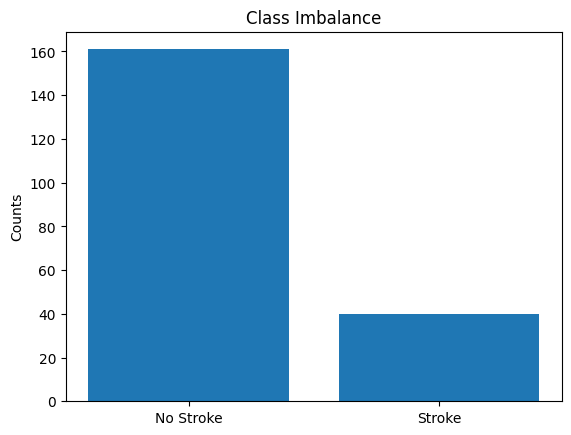

In [6]:
counts = df['stroke'].value_counts()
plt.bar(counts.index, counts.values)
plt.xticks((0, 1), ('No Stroke', 'Stroke'))
plt.ylabel('Counts')
plt.title('Class Imbalance')
plt.savefig("imbalance.png")
plt.show()
plt.close()

From the result above, you can see that we have an imbalance where the minority class is the people with strokes.

We will need to address this either using SMOTE or Cost-Sensitive Learning because in our case, we want to have more examples of the minority class for our models to understand the cases where people have brain strokes.

In [7]:
# Features and their types
X = df.drop(columns='stroke')
y = df['stroke']

numeric_features = X.select_dtypes(include=['float']).columns.to_list()
category_features = X.select_dtypes(exclude=['float']).columns.to_list()

print(f'Numerical Features: {numeric_features}')
print()
print(f'Categorical Features: {category_features}')
print()

# The unique values in each categorical feature to determine whether they are nomial or ordinal
for column in category_features:
    unique_values = sorted(X[column].unique())
    print(f"The Unique Values in {column} are: {unique_values}")
    print()

Numerical Features: ['age', 'avg_glucose_level', 'bmi']

Categorical Features: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

The Unique Values in gender are: ['Female', 'Male']

The Unique Values in hypertension are: ['No', 'Yes']

The Unique Values in heart_disease are: ['No', 'Yes']

The Unique Values in ever_married are: ['No', 'Yes']

The Unique Values in work_type are: ['Govt_job', 'Private', 'Self-employed', 'children']

The Unique Values in Residence_type are: ['Rural', 'Urban']

The Unique Values in smoking_status are: ['Unknown', 'formerly smoked', 'never smoked', 'smokes']



From the results above, the only categorical feature that could be a smoking status. However, The ordinal order of it will be interesting because Unknown means it be anyting in terms of amount of smoking. 

The ordering might be 'never smoked', 'Unknown', 'formerly smoked', and 'smokes'. 

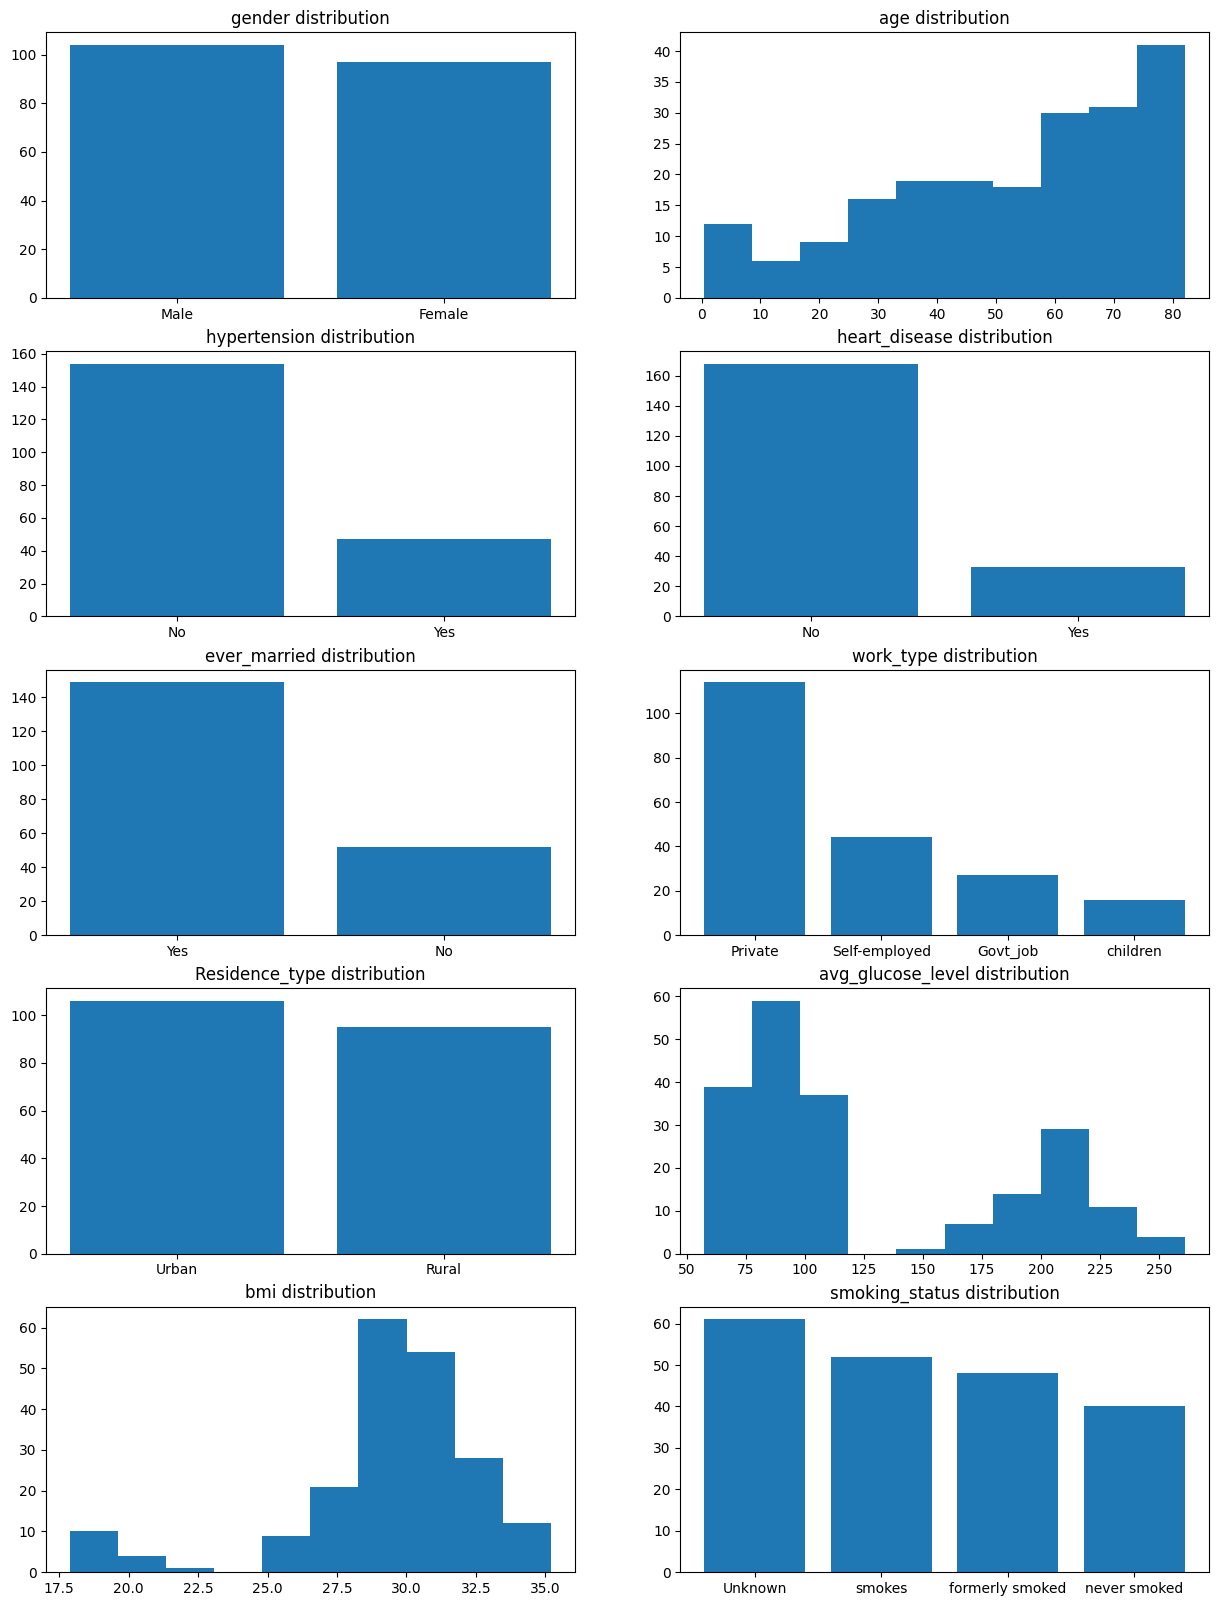

In [8]:
# Distribution of features
fig, axes = plt.subplots(5, 2, figsize=(15,20))

flat_axes = axes.flatten()

for column, ax in zip(X.columns, flat_axes):
    
    if column in numeric_features:
        ax.hist(df[column])
    else:
        counts = df[column].value_counts()
        ax.bar(counts.index, counts.values)
    
    ax.set_title(f'{column} distribution')

fig.savefig(fname='features_distributions.png')

From the histograms above, we can see Hypertension, Ever Married, and Heart Disease features have a lot of imbalance, as they skew right.

The average glucose levels and bmi distibutions are very similar but in reverse, where one part looks normally distribution and another part is separate. 

The smoking status and gender distributions is fairly well balanced. 

The Age distributions skew slightly left, which makes sense since the older 
an individual is, the more likely the person will have brain stroke.



age                  0.353495
avg_glucose_level   -0.040227
bmi                  0.003663
dtype: float64

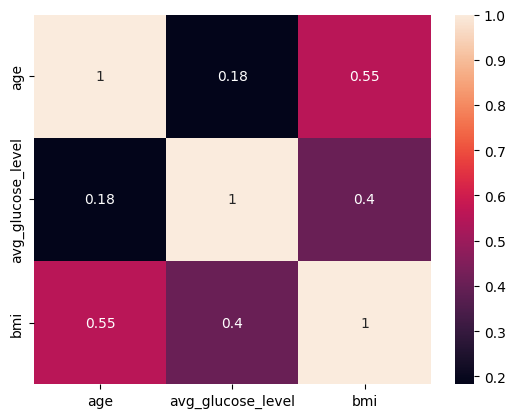

In [9]:
# Correlation Matrix for numerical features with each other
num_features = X.select_dtypes(include=['float'])
correlation = sns.heatmap(num_features.corr(), annot=True)
figure = correlation.get_figure()
figure.savefig(fname="correlation_heatmap.png")

# How correlated are numerical features to the label
num_features.corrwith(y)

From the data, it looks like age has the highest correlation to having a brain stroke, which makes sense since older people usually suffer strokes just in general. 

From the Heatmap, bmi and age have the biggest correlation, followed by average glucose level and bmi. 
These make sense intuitively since having a higher age means you might have a higher bmi and a higher average glucose level 
probably means having a higher bmi.

## Data Preprocessing

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [11]:
numerical_features = X[numeric_features]
categorical_features = X[category_features]

# Numerical Pipeline 
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline(steps=[
('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OneHotEncoder(handle_unknown='ignore'))])

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, X.select_dtypes(include=['float']).columns),
    ('cat', categorical_pipeline, X.select_dtypes(exclude=['float']).columns)
])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# SMOTE
smote_x, smote_y = SMOTE(sampling_strategy=0.5, random_state=42).fit_resample(X_train, y_train)

## Model Training + Evaluation

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

For this project, I will used the hyperparameters found in the paper for all the models outside of catboost. I will utilize gridsearch for catboost for hyperparameter tuning

CatBoost has their own version of grid search cross validation so I will use that for the its hyperparameter tuning

In [14]:
# These values are based on the paper
knn_model = KNeighborsClassifier(n_neighbors=7)
lr_model = LogisticRegression(C=1.0, solver='liblinear', random_state=42)
rf_model = RandomForestClassifier(criterion='entropy', max_depth=9, max_features='log2', n_estimators=88, random_state=42)
svm_model = svm.SVC(C=10, kernel='rbf', gamma=1, probability=True, random_state=42)

xgboost_params = {
    'colsample_bytree': 0.6143,
    'learning_rate': 0.6959,
    'max_depth': 8,
    'min_child_weight': 1,
    'n_estimators': 283,
    'subsample': 0.5813,
    'random_state': 42
}

xgboost_model = XGBClassifier(**xgboost_params)
catboost_model_no_tuning = CatBoostClassifier(silent=True, random_seed=42)
catboost_model = CatBoostClassifier(silent=True, random_seed=42)


### Hyperparameter Tuning at Catboost

We will perform hyperparameter tuning on Catboost utilizing random earch

In [15]:
catboost_params = {
    'iterations': np.arange(100, 1000, step=10), 
    'learning_rate': np.arange(0.01, 1, step=0.01),
    'depth': np.arange(1, 8, step=1),
    'l2_leaf_reg': np.arange(1, 10, step=1),
}

catboost_model.randomized_search(catboost_params, smote_x, smote_y, cv=10, n_iter=100)



bestTest = 0.4295513713
bestIteration = 0

0:	loss: 0.4295514	best: 0.4295514 (0)	total: 160ms	remaining: 15.8s

bestTest = 0.4700908108
bestIteration = 202

1:	loss: 0.4700908	best: 0.4295514 (0)	total: 234ms	remaining: 11.4s

bestTest = 0.4640129335
bestIteration = 198

2:	loss: 0.4640129	best: 0.4295514 (0)	total: 305ms	remaining: 9.86s

bestTest = 0.4442229747
bestIteration = 9

3:	loss: 0.4442230	best: 0.4295514 (0)	total: 397ms	remaining: 9.54s

bestTest = 0.4346174625
bestIteration = 0

4:	loss: 0.4346175	best: 0.4295514 (0)	total: 487ms	remaining: 9.26s

bestTest = 0.4706106055
bestIteration = 381

5:	loss: 0.4706106	best: 0.4295514 (0)	total: 608ms	remaining: 9.53s

bestTest = 0.4784303826
bestIteration = 449

6:	loss: 0.4784304	best: 0.4295514 (0)	total: 732ms	remaining: 9.72s

bestTest = 0.4479410443
bestIteration = 9

7:	loss: 0.4479410	best: 0.4295514 (0)	total: 886ms	remaining: 10.2s

bestTest = 0.4436291847
bestIteration = 10

8:	loss: 0.4436292	best: 0.4295514 (0)	tota

{'params': {'depth': 6,
  'learning_rate': 0.93,
  'l2_leaf_reg': 6,
  'iterations': 980},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45

From the code, we can see that these is our best hyperparameters for this model

In [16]:
models = [('KNN', knn_model), ('LR', lr_model),('RF', rf_model), ('SVM', svm_model), ('XGB', xgboost_model), ('CatBoost Default', catboost_model_no_tuning), ('CatBoost Tuning', catboost_model)]

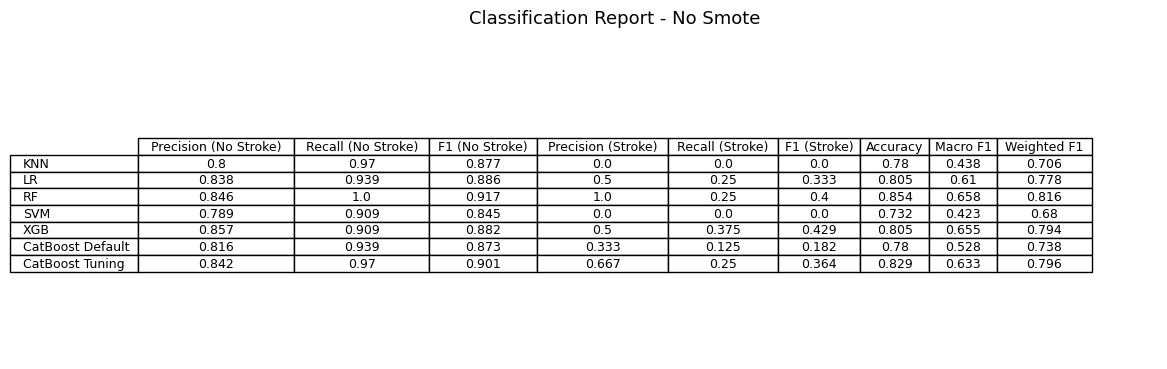

In [17]:
# Training and Evaluation without SMOTE
final_report_no_smote = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    final_report_no_smote.append({
        'Model': name,
        'Precision (No Stroke)': report['0']['precision'],
        'Recall (No Stroke)': report['0']['recall'],
        'F1 (No Stroke)': report['0']['f1-score'],
        'Precision (Stroke)': report['1']['precision'],
        'Recall (Stroke)': report['1']['recall'],
        'F1 (Stroke)': report['1']['f1-score'],
        'Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
    })

results_no_smote = pd.DataFrame(final_report_no_smote).set_index('Model').round(3)
results_no_smote.to_csv("classification_report_no_smote.csv")

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

table = ax.table(
    cellText=results_no_smote.values,
    rowLabels=results_no_smote.index,
    colLabels=results_no_smote.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(results_no_smote.columns))))

ax.set_title('Classification Report - No Smote', fontsize=13, pad=20)
fig.savefig('classification_report_no_smote.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()



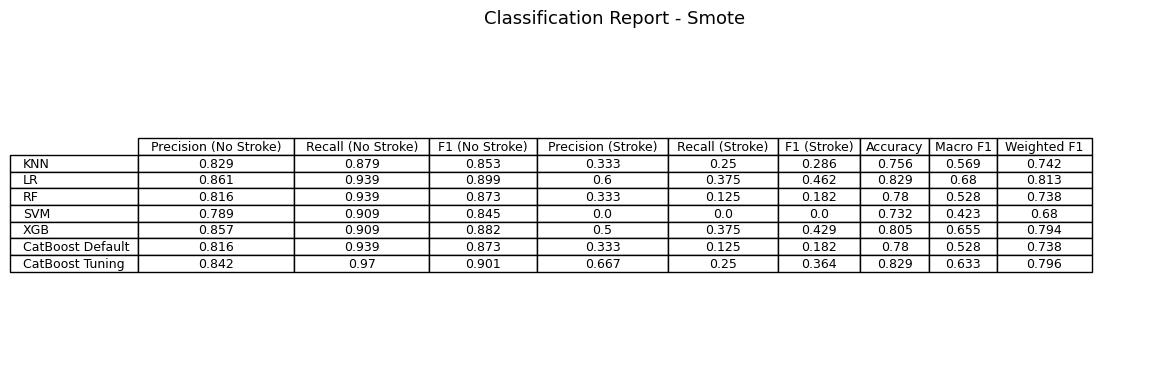

In [18]:
# Training and Evaluation with SMOTE
final_report_with_smote = []
for name, model in models:
    model.fit(smote_x, smote_y)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    final_report_with_smote.append({
        'Model': name,
        'Precision (No Stroke)': report['0']['precision'],
        'Recall (No Stroke)': report['0']['recall'],
        'F1 (No Stroke)': report['0']['f1-score'],
        'Precision (Stroke)': report['1']['precision'],
        'Recall (Stroke)': report['1']['recall'],
        'F1 (Stroke)': report['1']['f1-score'],
        'Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
    })

results_smote = pd.DataFrame(final_report_with_smote).set_index('Model').round(3)
results_smote.to_csv("classification_report_smote.csv")
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

table = ax.table(
    cellText=results_smote.values,
    rowLabels=results_smote.index,
    colLabels=results_smote.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(results_smote.columns))))

ax.set_title('Classification Report - Smote', fontsize=13, pad=20)
fig.savefig('classification_report_smote.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close(fig)



## Feature Importance

In [19]:
from sklearn.inspection import permutation_importance

In [20]:
for name, model in models:
    fig, ax = plt.subplots(figsize=(16, 20))
    importance = None
    if hasattr(model, 'feature_importances_'):
        print(f"Feature Importance: {name}")
        importance = model.feature_importances_
    elif hasattr(model, 'coef_'):
        print(f"Coefficient: {name}")
        importance = np.abs(model.coef_[0])
    else:
        print(f"Permutation Importance: {name}")
        importance = np.abs(permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42).importances_mean)

    one_hot_encoded_features = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(category_features)
    importance_df = pd.DataFrame({
    'Feature': numeric_features + list(one_hot_encoded_features),
    'Importance': importance}).sort_values('Importance', ascending=False)

    ax.bar(importance_df['Feature'], importance_df['Importance'], color='Aqua')
    ax.set_title(f'{name} Feature Importance')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    fig.savefig(f'feature_importance_{name}.png')
    plt.close(fig)

Permutation Importance: KNN
Coefficient: LR
Feature Importance: RF
Permutation Importance: SVM
Feature Importance: XGB
Feature Importance: CatBoost Default
Feature Importance: CatBoost Tuning


# Analysis and Interpretation

## NOTE: For the presentation on April 22, I didn't use properly instaniate random values in the models, use the proper SMOTE function, and didn't initiate correct catboost parameter values to search over. So, the results as going to be different between this final paper/repo and the presentation. This is something I just want to add in just for clarification

When looking at feature importance, the most consistent feature that was high in importance was age. The feature that was pretty consistently low was work type (children).

The Model that performed best based on F1 score was Logistic Regression that used SMOTE data. Utilizing hyperparameter tuning for CatBoost was beneficial as well.

Based on the results from the classification reports, utilizing SMOTE was a good method to raise the precision and recall for the for KNN and Logistic Regression. However, it didn't provide support for Random Forest, SVM, XGBoost, and CatBoost.

There are better internal methods that CatBoost and XGBoost has, like scaled position weight, which puts a higher weight on the minority class without the need to create synthetic data that could be noisy.

When utilizing SMOTE, you could generate synthetic data that is near the decision boundary, and maybe near the majority class. As a result, you might not see any improvements in metrics for the Stroke data when using the SVM model. 

For the Random Forest, similar the SVM, you could be generating synthetic data near clusters of other data, which can lead to overfitting. As a result, there could be low metrics on testing data. 

In the future, I could utilize better ways of handling class imbalance, such as other versions of SMOTE or other class imbalancing methods, especially for the XGBoost and CatBoost models. In addition, I didn't utilize hyperparmeter tuning to the models outside of CatBoost. That is something that I could implement in the future as well. I also can try to find more datasets that have either more features or less severe class imbalances.

# Comparison to Existing Work

For this project, I used this paper titled "Performance Comparison of Various Machine Learning Approaches to Identify the Best One
in Predicting Heart Disease". The reason I used this paper was because they had a similar goal of finding best machine learning model for medical diagnosis and they used a dataset that had very similar features. In addition, for the models outside of CatBoost, I used the same hyperparameters as used in the paper since the Kaggle dataset used in the paper had similar features. 

There are some differences between my project and this paper. The biggest difference in that the datasets used in the paper do not have a severe class imbalance compared to my dataset. The splits for the Kaggle dataset used in the paper is around 51.7% and 48.3%, Stroke and no Stroke respectively. As a results, the precision and recall metrics for the same models between these projects were high for the paper than my project. For example, I had a weighted 0.742 F1 score for my KNN model with SMOTE data, while the paper had a weight F1 of 1.0 on the Kaggle dataset similar to my dataset. In addition, the paper used hyperparameter tuning with cross validation of 10 on all the models. This could also explain why my models are as accurate was the papers, even if the medical conditions we are looking at are different (heart disease for the paper, and brain stroke for my project). 

In conclusion, I believe I should follow the paper's framework of utilizing hyperparameter tuning on all the models in the future.

# Read World or Social Impact

Machine learning is being used in the healthcare and medical field. I believe understand what machine learning frameworks, such as preprocessing, types of models, and validation techniques are critical for something as serious as medical diagnosis. I believe with some tweaks I could make with from this project, such as using more models or hyperparameter tuning all the models, could become a reliable framework to figure our which frameworks and models work best for specific medical and healthcare situations such as treatments, diagnosis, prevention, or other important situation. 

I think the one big issue that would be be a critical issue in the future is the class imbalance. This could lead to lots of missed positive cases, which simply cannot happen. This would become a ethical concern if these models are making final decisions in these situations. As a result, there needs to be more robust way of dealing with class imbalance in order to ensure that we are not missing people with diseases. 

From this project, there is a ton of potential with using machine learning models for medical predictions; however, there needs to be reliable ways of dealing with class/data imbalance in order to reduce these models missing cases. This project truly highlights the importance of data when it comes to reliable machine learning models. As a result, I think it is best to use these machine learning models for recognizing patterns, but doctors should make the final decision for these diagnoses. 